In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('golden_mine.csv', encoding = 'utf-8')
pd.set_option('display.float_format', '{:.2f}'.format)

# Первичный осмотр данных

In [ ]:
df.head(5)

,Payments,Costs,Profit,Age,Gender,AgeGroup
0,9400,8100,1300,19,male,18-24
1,26600,13900,12700,29,male,25-39
2,9750,6750,3000,20,male,18-24
3,29700,11200,18500,18,female,18-24
4,49700,10450,39250,21,female,18-24


In [ ]:
df.tail(5)

,Payments,Costs,Profit,Age,Gender,AgeGroup
8710,8650,8600,50,18,male,18-24
8711,45350,14350,31000,19,female,18-24
8712,41700,9900,31800,18,female,18-24
8713,120600,49650,70950,21,male,18-24
8714,21700,13150,8550,33,Female,25-39


In [ ]:
df.shape

(8715, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8715 entries, 0 to 8714
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Payments  8715 non-null   int64 
 1   Costs     8715 non-null   int64 
 2   Profit    8715 non-null   int64 
 3   Age       8715 non-null   int64 
 4   Gender    8715 non-null   object
 5   AgeGroup  8715 non-null   object
dtypes: int64(4), object(2)
memory usage: 408.6+ KB


In [ ]:
df.describe()

,Payments,Costs,Profit,Age
count,8715.00,8715.00,8715.00,8715.00
mean,30097.87,14690.63,15407.25,22.39
std,76051.24,103661.75,127100.50,5.88
min,3750.00,3500.00,-9643950.00,18.00
25%,10800.00,8350.00,2500.00,18.00
50%,19850.00,11450.00,7850.00,19.00
75%,40050.00,15350.00,23750.00,25.00
max,6654600.00,9661700.00,6643950.00,49.00


# Очистка данных

### 1. Обработка выбросов

Из первичного осмотра данных, обратим внимание на то, что есть большая разница между максимальным значением Profit и 75% квантилем, а так же между  минимальным значением Profit и 25% квантилем. Скорее всего максимальное и минимальное значение Profit являяются выборосами.

Посторим boxplot и гистограмму по Profit на основе датасета

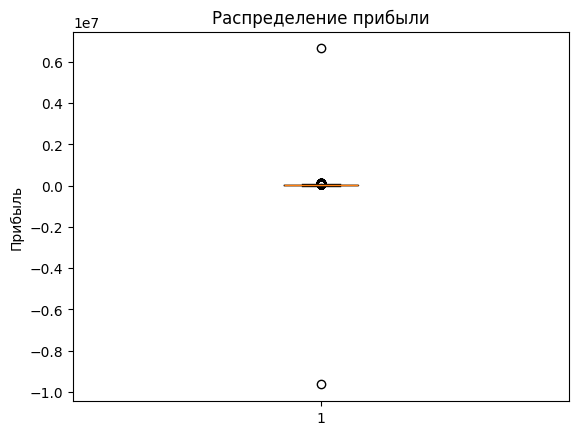

In [ ]:
plt.figure()
plt.boxplot(df['Profit'])
plt.title('Распределение прибыли')
plt.ylabel('Прибыль')
plt.show()

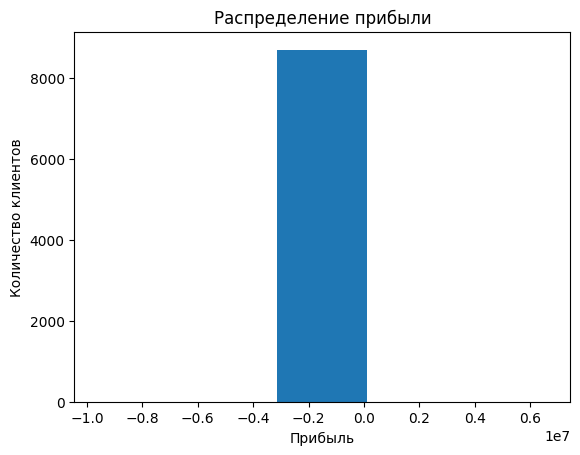

In [ ]:
plt.figure()
plt.hist(df['Profit'], bins=5)
plt.title('Распределение прибыли')
plt.xlabel('Прибыль')
plt.ylabel('Количество клиентов')
plt.show()

Обратим внимание на то, что в boxplot четко видны 2 выброса. А в гистограмме все данные слилсь в один столбец, что подтверждает наличие сильных выбросов в данных.

Попробуем удалить максимальное и минимальное значения Profit и посмотрим, как изменится ситуация.

Начнём с максимального:

In [ ]:
max_profit = (df['Profit'] == df['Profit'].max())
df = df.loc[~max_profit]
df.describe()

,Payments,Costs,Profit,Age
count,8714.00,8714.00,8714.00,8714.00
mean,29337.66,14691.09,14646.57,22.39
std,27336.09,103667.69,105418.45,5.88
min,3750.00,3500.00,-9643950.00,18.00
25%,10800.00,8350.00,2500.00,18.00
50%,19850.00,11450.00,7850.00,19.00
75%,40050.00,15350.00,23750.00,25.00
max,148300.00,9661700.00,109500.00,49.00


Выброс удалили, отсортируем DF по возрастанию Profit и увидим, что в последних 10-ти строках данных значение Profit примерно одинаково, значит выбросов тут нет.

In [ ]:
df.sort_values('Profit', inplace=False).tail(10)

,Payments,Costs,Profit,Age,Gender,AgeGroup
2651,138900,36050,102850,21,male,18-24
6658,136950,33900,103050,21,male,18-24
1047,143000,39600,103400,21,male,18-24
3619,148300,44850,103450,24,male,18-24
6340,141500,37800,103700,21,male,18-24
1995,137500,33750,103750,21,male,18-24
6378,143400,39500,103900,22,male,18-24
7408,137950,32700,105250,21,male,18-24
8420,139100,33150,105950,22,male,18-24
2941,145250,35750,109500,21,male,18-24


Теперь минимальное:

In [ ]:
min_profit = (df['Profit'] == df['Profit'].min())
df = df.loc[~min_profit]
df.describe()

,Payments,Costs,Profit,Age
count,8713.00,8713.00,8713.00,8713.00
mean,29338.99,13583.89,15755.10,22.39
std,27337.37,8039.31,20125.91,5.88
min,3750.00,3500.00,-10200.00,18.00
25%,10800.00,8350.00,2500.00,18.00
50%,19850.00,11450.00,7850.00,19.00
75%,40050.00,15350.00,23750.00,25.00
max,148300.00,54350.00,109500.00,49.00


Выброс удалили, отсортируем DF по убыванию Profit и увидим, что в последних 10-ти строках данных значение Profit примерно одинаково, значит выбросов тут нет.

In [ ]:
df.sort_values('Profit', inplace=False, ascending=False).tail(10)

,Payments,Costs,Profit,Age,Gender,AgeGroup
5759,5000,10050,-5050,18,male,18-24
2077,10150,15550,-5400,28,male,25-39
4916,6600,12050,-5450,29,male,25-39
2329,6250,12000,-5750,30,FEMALE,25-39
4512,10050,15950,-5900,27,male,25-39
5457,3750,10000,-6250,18,male,18-24
606,7350,14350,-7000,28,FEMALE,25-39
8572,8400,15550,-7150,25,female,25-39
4698,6800,16600,-9800,36,Female,25-39
3179,6750,16950,-10200,33,male,25-39


Посмотрим новые boxplot и гистограмму

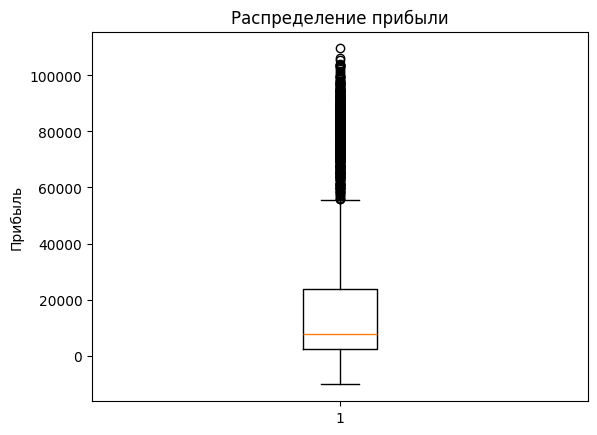

In [ ]:
plt.figure()
plt.boxplot(df['Profit'])
plt.title('Распределение прибыли')
plt.ylabel('Прибыль')
plt.show()

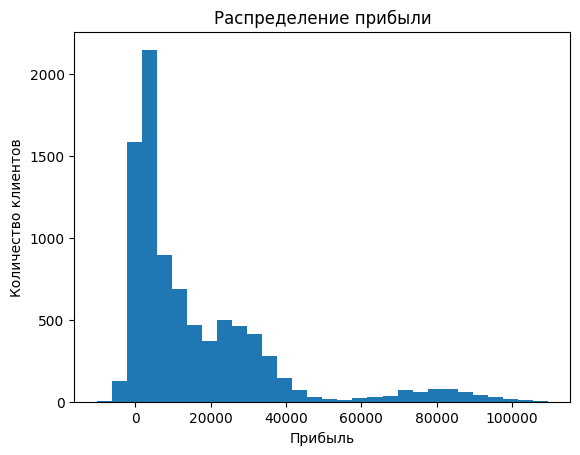

In [ ]:
plt.figure()
plt.hist(df['Profit'], bins=30)
plt.title('Распределение прибыли')
plt.xlabel('Прибыль')
plt.ylabel('Количество клиентов')
plt.show()

Теперь графики выглядят хорошо и на них нет выбросов. У нас есть полностью готовый DataFrame для дальнейшей работы.

# Текущая ситуация

### Количество клиентов

In [ ]:
amount_clients = df.shape[0]
amount_clients

8713

### Прибль от одного клиента

In [ ]:
avg_profit = df['Profit'].mean()

new_clients = 1000
cac = 15_000

avg_profit

np.float64(15755.095833811545)

### Привлечение клиентов без таргетирования пола или возраста

Общая стоимость привлечения новых клиентов

In [ ]:
total_cost = new_clients * cac
total_cost

15000000

Ожидаемая прибль

In [ ]:
exepted_profit = avg_profit * new_clients
new_profit = exepted_profit - total_cost
new_profit

np.float64(755095.8338115457)

# Расчёт прибыли в каждой половозрастной группе

In [ ]:
grouped = df.groupby(['Gender', 'AgeGroup'])['Profit'].agg(['mean', 'count', 'sum'])
grouped

mean  count       sum
Gender AgeGroup                          
FEMALE 25-39     7481.74    230   1720800
Female 25-39     7896.11    604   4769250
female 18-24    26278.37   2712  71266950
       25-39     8094.97    378   3059900
       40+       -343.75     72    -24750
male   18-24    13155.76   3679  48400050
       25-39     7927.82   1019   8078450
       40+        184.21     19      3500

Видим, что female записан 3 раза в разных регистрах. Исправим это, заменив всё на один вид.

In [ ]:
df = df.replace({'FEMALE': 'female', 'Female': 'female'})
grouped = df.groupby(['Gender', 'AgeGroup'])['Profit'].agg(['mean', 'count', 'sum'])
grouped

mean  count       sum
Gender AgeGroup                          
female 18-24    26278.37   2712  71266950
       25-39     7879.50   1212   9549950
       40+       -343.75     72    -24750
male   18-24    13155.76   3679  48400050
       25-39     7927.82   1019   8078450
       40+        184.21     19      3500

Разделим самую прибыльную категорию 18-24 лет на две равные части: 18-20 и 18-24, сохранив распредление по полу. Посчитаем средний Profit для каждой из новых категорий.

In [ ]:
print('Средний Profit с клиента в категории "Женщины 18-20 лет', df[df['Age'].between(18, 20) & (df['Gender'] == 'female')]['Profit'].mean())
print('Средний Profit с клиента в категории "Женщины 21-24 лет', df[df['Age'].between(21, 24) & (df['Gender'] == 'female')]['Profit'].mean())

Средний Profit с клиента в категории "Женщины 18-20 лет 25100.097943192948
Средний Profit с клиента в категории "Женщины 21-24 лет 29869.4776119403


In [ ]:
print('Средний Profit с клиента в категории "Мужчины 18-20 лет', df[df['Age'].between(18, 20) & (df['Gender'] == 'male')]['Profit'].mean())
print('Средний Profit с клиента в категории "Мужчины 21-24 лет', df[df['Age'].between(21, 24) & (df['Gender'] == 'male')]['Profit'].mean())

Средний Profit с клиента в категории "Мужчины 18-20 лет 2042.111111111111
Средний Profit с клиента в категории "Мужчины 21-24 лет 79333.45935727788


Объединим категории "Мужчины 21-24 лет" и "Женщины 21-24 лет"

In [ ]:
print('Средний Profit с клиента в категории "Мужчины и женщины 21-24 лет', df[df['Age'].between(21, 24)]['Profit'].mean())

Средний Profit с клиента в категории "Мужчины и женщины 21-24 лет 51693.03586321935
